In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o")

## Customer support tools

In [3]:
import datetime
from collections import defaultdict
from typing import Callable

from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm

# Mock data for tools
RESERVATIONS = defaultdict(lambda: {"flight_info": {}, "hotel_info": {}})
TOMORROW = (datetime.date.today() + datetime.timedelta(days=1)).isoformat()
FLIGHTS = [
    {
        "departure_airport": "BOS",
        "arrival_airport": "JFK",
        "airline": "Jet Blue",
        "date": TOMORROW,
        "id": "1",
    }
]
HOTELS = [
    {
        "location": "New York",
        "name": "McKittrick Hotel",
        "neighborhood": "Chelsea",
        "id": "1",
    }
]


# Flight tools
def search_flights(
    departure_airport: str,
    arrival_airport: str,
    date: str,
) -> list[dict]:
    """Search flights.

    Args:
        departure_airport: 3-letter airport code for the departure airport. If unsure, use the biggest airport in the area
        arrival_airport: 3-letter airport code for the arrival airport. If unsure, use the biggest airport in the area
        date: YYYY-MM-DD date
    """
    # return all flights for simplicity
    return FLIGHTS


def book_flight(
    flight_id: str,
    config: RunnableConfig,
) -> str:
    """Book a flight."""
    user_id = config["configurable"].get("user_id")
    flight = [flight for flight in FLIGHTS if flight["id"] == flight_id][0]
    RESERVATIONS[user_id]["flight_info"] = flight
    return "Successfully booked flight"


# Hotel tools
def search_hotels(location: str) -> list[dict]:
    """Search hotels.

    Args:
        location: offical, legal city name (proper noun)
    """
    # return all hotels for simplicity
    return HOTELS


def book_hotel(
    hotel_id: str,
    config: RunnableConfig,
) -> str:
    """Book a hotel."""
    user_id = config["configurable"].get("user_id")
    hotel = [hotel for hotel in HOTELS if hotel["id"] == hotel_id][0]
    RESERVATIONS[user_id]["hotel_info"] = hotel
    return "Successfully booked hotel"


# Handoff tools
transfer_to_hotel_assistant = create_handoff_tool(
    agent_name="hotel_assistant",
    description="Transfer user to the hotel-booking assistant that can search for and book hotels.",
)
transfer_to_flight_assistant = create_handoff_tool(
    agent_name="flight_assistant",
    description="Transfer user to the flight-booking assistant that can search for and book flights.",
)


# Define agent prompt
def make_prompt(base_system_prompt: str) -> Callable[[dict, RunnableConfig], list]:
    def prompt(state: dict, config: RunnableConfig) -> list:
        user_id = config["configurable"].get("user_id")
        current_reservation = RESERVATIONS[user_id]
        system_prompt = (
            base_system_prompt
            + f"\n\nUser's active reservation: {current_reservation}"
            + f"Today is: {datetime.datetime.now()}"
        )
        return [{"role": "system", "content": system_prompt}] + state["messages"]

    return prompt


# Define agents
flight_assistant = create_react_agent(
    model,
    [search_flights, book_flight, transfer_to_hotel_assistant],
    prompt=make_prompt("You are a flight booking assistant"),
    name="flight_assistant",
)

hotel_assistant = create_react_agent(
    model,
    [search_hotels, book_hotel, transfer_to_flight_assistant],
    prompt=make_prompt("You are a hotel booking assistant"),
    name="hotel_assistant",
)

# Compile and run!
checkpointer = MemorySaver()
builder = create_swarm(
    [flight_assistant, hotel_assistant], default_active_agent="flight_assistant"
)

# Important: compile the swarm with a checkpointer to remember
# previous interactions and last active agent
app = builder.compile(checkpointer=checkpointer)

In [4]:
from IPython.display import Image, display

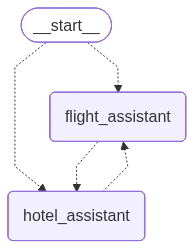

In [5]:
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
import uuid

config = {"configurable": {"thread_id": str(uuid.uuid4()), "user_id": "1"}}

In [7]:
def print_stream(stream):
    for ns, update in stream:
        for node, node_updates in update.items():
            if node_updates is None:
                continue

            if isinstance(node_updates, (dict, tuple)):
                node_updates_list = [node_updates]
            elif isinstance(node_updates, list):
                node_updates_list = node_updates
            else:
                raise ValueError(node_updates)

            for node_updates in node_updates_list:
                if isinstance(node_updates, tuple):
                    continue
                messages_key = next(
                    (k for k in node_updates.keys() if "messages" in k), None
                )
                if messages_key is not None:
                    node_updates[messages_key][-1].pretty_print()
                else:
                    pass



In [8]:
print_stream(
    app.stream(
        {
            "messages": [
                {
                    "role": "user",
                    "content": "i am looking for a flight from boston to ny tomorrow",
                }
            ]
        },
        config,
        subgraphs=True,
    )
)

================================== Ai Message ==================================
Name: flight_assistant
Tool Calls:
  search_flights (call_BtunQV2s9w4zGYIK4xgtUU9G)
 Call ID: call_BtunQV2s9w4zGYIK4xgtUU9G
  Args:
    departure_airport: BOS
    arrival_airport: JFK
    date: 2025-11-09
================================= Tool Message =================================
Name: search_flights

[{"departure_airport": "BOS", "arrival_airport": "JFK", "airline": "Jet Blue", "date": "2025-11-09", "id": "1"}]
================================== Ai Message ==================================
Name: flight_assistant

I found a flight for you from Boston (BOS) to New York (JFK) for tomorrow, November 9, 2025. The flight is with Jet Blue. Would you like to book this flight?
================================== Ai Message ==================================
Name: flight_assistant

I found a flight for you from Boston (BOS) to New York (JFK) for tomorrow, November 9, 2025. The flight is with Jet Blue. Would yo

In [9]:
print_stream(
    app.stream(
        {"messages": [{"role": "user", "content": "yes please"}]},
        config,
        subgraphs=True,
    )
)

================================== Ai Message ==================================
Name: flight_assistant
Tool Calls:
  book_flight (call_aPMKRGk5NnyjvTSgO6abs4AJ)
 Call ID: call_aPMKRGk5NnyjvTSgO6abs4AJ
  Args:
    flight_id: 1
================================= Tool Message =================================
Name: book_flight

Successfully booked flight
================================== Ai Message ==================================
Name: flight_assistant

Your flight from Boston (BOS) to New York (JFK) with Jet Blue for tomorrow, November 9, 2025, has been successfully booked. If you need help with anything else, feel free to ask!
================================== Ai Message ==================================
Name: flight_assistant

Your flight from Boston (BOS) to New York (JFK) with Jet Blue for tomorrow, November 9, 2025, has been successfully booked. If you need help with anything else, feel free to ask!


In [10]:
print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": "now i'd like to book a hotel as well"}
            ]
        },
        config,
        subgraphs=True,
    )
)

================================== Ai Message ==================================
Name: flight_assistant
Tool Calls:
  transfer_to_hotel_assistant (call_fpfaV67jrHijxYoXoOxpspOW)
 Call ID: call_fpfaV67jrHijxYoXoOxpspOW
  Args:
================================= Tool Message =================================
Name: transfer_to_hotel_assistant

Successfully transferred to hotel_assistant
================================== Ai Message ==================================
Name: hotel_assistant
Tool Calls:
  search_hotels (call_WZE45u1dSYUqRnOsUMQMdsLS)
 Call ID: call_WZE45u1dSYUqRnOsUMQMdsLS
  Args:
    location: New York
================================= Tool Message =================================
Name: search_hotels

[{"location": "New York", "name": "McKittrick Hotel", "neighborhood": "Chelsea", "id": "1"}]
================================== Ai Message ==================================
Name: hotel_assistant

I found a hotel for you in New York:

- **McKittrick Hotel** located in the Chels

In [11]:
print_stream(
    app.stream(
        {"messages": [{"role": "user", "content": "yes please"}]},
        config,
        subgraphs=True,
    )
)

================================== Ai Message ==================================
Name: hotel_assistant
Tool Calls:
  book_hotel (call_e5vyun3y5wu82ucyZ0nlicWe)
 Call ID: call_e5vyun3y5wu82ucyZ0nlicWe
  Args:
    hotel_id: 1
================================= Tool Message =================================
Name: book_hotel

Successfully booked hotel
================================== Ai Message ==================================
Name: hotel_assistant

Your room at the McKittrick Hotel in Chelsea, New York, has been successfully booked. If there's anything else you need, feel free to let me know!
================================== Ai Message ==================================
Name: hotel_assistant

Your room at the McKittrick Hotel in Chelsea, New York, has been successfully booked. If there's anything else you need, feel free to let me know!


In [12]:
print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": "i wanna talk to flight assistant now"}
            ]
        },
        config,
        subgraphs=True,
    )
)

================================== Ai Message ==================================
Name: hotel_assistant
Tool Calls:
  transfer_to_flight_assistant (call_ixrfEy6cg0uoVW4Ut39bU1Qn)
 Call ID: call_ixrfEy6cg0uoVW4Ut39bU1Qn
  Args:
================================= Tool Message =================================
Name: transfer_to_flight_assistant

Successfully transferred to flight_assistant
================================== Ai Message ==================================
Name: flight_assistant

You are now back with the flight assistant. How can I assist you further with your travel needs?
================================== Ai Message ==================================
Name: flight_assistant

You are now back with the flight assistant. How can I assist you further with your travel needs?
